In [ ]:
#Cloning the repository to colab
!git clone https://github.com/Maame-Pokuaa77/lab-2-predictive-analytics.git

Cloning into 'lab-2-predictive-analytics'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
#Moving into the repository
%cd lab-2-predictive-analytics

/content/lab-2-predictive-analytics


In [ ]:
#Creating Requirements.txt

%%writefile requirements.txt
numpy
pandas
scikit-learn
matplotlib
seaborn


Writing requirements.txt


In [ ]:
#Veryfying if file was created

!ls

README.md  requirements.txt


In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

(41202, 13)
<bound method NDFrame.head of        VendorID  passenger_count  trip_distance  RatecodeID  \
0             2                1          17.63           2   
1             2                1          19.52           2   
2             2                1          17.81           2   
3             2                2          19.30           2   
4             2                1          18.75           2   
...         ...              ...            ...         ...   
41197         2                1          16.94           2   
41198         2                4          19.83           2   
41199         2                1          17.31           2   
41200         2                1          17.28           2   
41201         2                1          16.82           2   

       store_and_fwd_flag  PULocationID  DOLocationID  payment_type  \
0                       1           132           164             1   
1                       1           132           236      

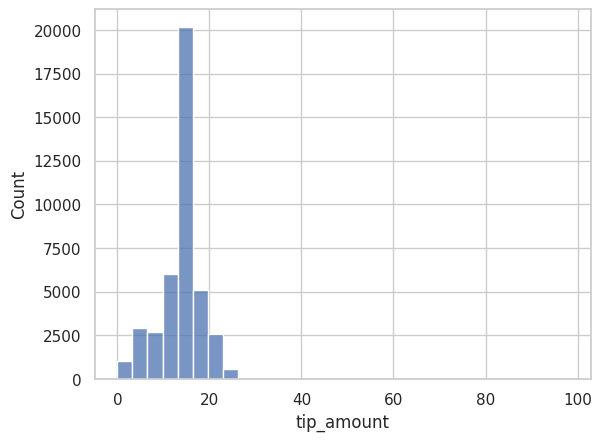

In [ ]:
#Section1 - Supervised Learning :Regression
#Predicting Taxi:Tip Amount
#Part 1.1 — Load and explore the taxi data

# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv")

# TODO: Inspect it
# - taxi.shape, taxi.head(), taxi.info()
print(taxi.shape)
print(taxi.head)
print(taxi.info())
# - taxi.describe()
print(taxi.describe())
# - count missing values per column: taxi.isna().sum()
print(taxi.isna().sum())

# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.
#Shape
#The distribution is slightly right-skewed.Most trips have tip amounts between 10 and
#20 with the highest frequency around 15.There are a fewer observations at higher tip amounts around
#25-30 creating a right tail.

#Extreme Values
#There are extreme values with unusually large tip amounts.
sns.histplot(data=taxi,x="tip_amount",bins=30)
plt.show()

#Taxi Data Exploration Answers
What is the shape of the data?
 The dataset has 41202 rows and 13 columns. There are 13 variables with 41202 observations with each row representing a taxi trip and each column representing factors about the trip(trip,fare, location and payment information).

Are there missing values or impossible values (e.g. negative tips, zero-distance trips)?
There are no missing values since every value of the column after running taxi.isna().sum() is 0.
Yes,there are impossible values.Considering all the minimum values of the variables after running the describe function, the trip distance is seen to have a minimum value of 0.00. A trip can't have a distance of exactly 0 so that's impossible.

What does the tip_amount distribution look like (skew, outliers, many zeros)?
The distribution of tip amounts is  right-skewed with most values between 10 and 20.
Yes,there is a presence of outliers. There are several unusually large tip amounts with a maximum of 98 dollars indicating the presence of outliers.
The dataset does not contain many zero tips since the minimum tip amount is 0.01.

How will this influence your preprocessing?
Since there are no missing values,there will be no need to do a missing-value imputation.Thee trips with a distance of zero need to be removed because they could be errors.Outliers may need to be removed or scaled because they can greatly influence regression models.


In [ ]:
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.
#There are no missing values

#Checking for invalid rows
(taxi["trip_distance"]<=0).sum()
#There are 76 rows wHere trip distance is zero so it will be removed

(taxi["fare_amount"] <= 0).sum()
#There are no rows with fare_amount <= 0
(taxi["tip_amount"] < 0).sum()
#There are no rows with fare_amount <= 0

#Removing rows with 0 trip distance
taxi = taxi[taxi["trip_distance"]>0]

#Investigate the new shape
taxi.shape
#The number of rows decreases indicating thatthe invalid rows were removed




# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

#Creating a new feature Total Surcharges which entails variables which represent extra cost added
#to the trip
taxi["total_surcharges"] = taxi["mta_tax"]+taxi["tolls_amount"]+taxi["improvement_surcharge"]

#Verify if it worked correctly
taxi[["mta_tax","tolls_amount","improvement_surcharge","total_surcharges"]].head()

#Confirming the right number of rows
len(taxi["total_surcharges"])

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

#Encoding Categoricals

categorical_columns= [
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag"
]

#Applying One-Hot Encoding
taxi_encoded = pd.get_dummies(taxi,columns = categorical_columns,drop_first= True)

#Verification if it worked
#Check new shape
print(f"Original Shape: {taxi.shape}")
print(f"Encoded Shape: {taxi_encoded.shape}")

#Check new columns
print(taxi_encoded.columns.tolist())

#Check first few rows
taxi_encoded.head()

#Separate features(X) and target(y)
y = taxi_encoded["tip_amount"]
X= taxi_encoded.drop("tip_amount",axis=1)

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
# TODO: Scale the numeric features.
from sklearn.preprocessing import StandardScaler   #(fit on TRAIN only — see Part 1.3)

Original Shape: (41126, 14)
Encoded Shape: (41126, 14)
['passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'fare_amount', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'tip_amount', 'total_surcharges', 'RatecodeID_2', 'RatecodeID_4', 'RatecodeID_5', 'store_and_fwd_flag_1']

X shape: (41126, 13)
y shape: (41126,)


1. How did you handle missing/invalid rows and why?
There were no missing values. There were 76 invalid rows where trip distance is 0 so it is removed.
The invalid rows were removed because in the long run,it would negativeky affect the model's performance.

2. Which new feature(s) did you engineer and what is the intuition behind them?
I engineered the Total surcharges feature which represents the sum of the variables which represent extra trip cost(mta_tax,tolls_amount,improvement_surcharge).
Intuition: Trips with higher surcharges may have varying characteristics and that could influence tipping behaviour. A customer tips differently when total trip costs are higher

3. Which scaling method did you choose and why is it appropriate here?
The StandardScaler fit only  scaling method was used on the training data to prevent data leakage. It's appropriate because,it standardizes features to mean =0 and std=1 which is needed because  features like trip_distance and passenger_count are on different scales.

In [ ]:
#Part 1.3 - Train/Validation/ Test Split

# TODO: Separate features (X) and target (y = tip_amount)
y = taxi_encoded["tip_amount"]
X= taxi_encoded.drop("tip_amount",axis=1)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

#First Split off the test set (20%)
X_temp,X_test,y_temp,y_test = train_test_split(
    X,y,
    test_size = 0.2,
    random_state = RANDOM_STATE
)

#Second split (split the remaining 80% ; 60% for train and 20% for validation)
X_train,X_val,y_train,y_val = train_test_split(
    X_temp,y_temp,
    #25% of X_temp = 20% of original
    test_size=0.25,
    random_state = RANDOM_STATE
)

#Check splits to verify
print(f"Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test: {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

#Scaling numeric features
#import standardscaler

from sklearn.preprocessing import StandardScaler

#Define numeric columns

#improvement_surcharge is not included because it has no variance
numeric_columns = [
    "passenger_count","trip_distance","PULocationID","DOLocationID",
    "fare_amount","mta_tax", "tolls_amount",
    "total_surcharges"
]

# TODO: Fit your scaler on the TRAINING set only,
 #initialise scaler

scaler = StandardScaler()

#Fit your scaler on training set only
scaler.fit(X_train[numeric_columns])
# then transform train, val, and test.

#Create copies to avoid modifying original dataframes
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()


#Transform train,val,test using the scaler fitted on training data
X_train_scaled[numeric_columns]= scaler.transform(X_train[numeric_columns])
X_val_scaled[numeric_columns]= scaler.transform(X_val[numeric_columns])
X_test_scaled[numeric_columns]= scaler.transform(X_test[numeric_columns])


#Veifying if scaling worked
print("Scaled training data statistics:")
print("Mean:",X_train_scaled[numeric_columns].mean().round(2))
print("Std:",X_train_scaled[numeric_columns].std().round(2))


Train: 24675 rows (60.0%)
Validation: 8225 rows (20.0%)
Test: 8226 rows (20.0%)
Scaled training data statistics:
Mean: passenger_count     0.0
trip_distance      -0.0
PULocationID        0.0
DOLocationID       -0.0
fare_amount         0.0
mta_tax            -0.0
tolls_amount        0.0
total_surcharges    0.0
dtype: float64
Std: passenger_count     1.0
trip_distance       1.0
PULocationID        1.0
DOLocationID        1.0
fare_amount         1.0
mta_tax             1.0
tolls_amount        1.0
total_surcharges    1.0
dtype: float64



The scaler must be fit on the training dataset only to prevent leakage and ensure the test set remains unseen. If scaling parameters(mean and standard deviation)  are calculated on the whole dataset,information from the validation and test sets would influence the training process.This would inflate the performance metrics of the model and give a false sense of accuracy since the model would have access to the test data indirectly.
Fitting only on training data  would guarantee that the model's evaluation metrics  reflects true real-world performance on new data.


I used a 60/20/20 split.
60%  for training,
20% for validation and 20% for test.


To enable us tune hyperparameters and  evaluate the model's performance during development without touching the test set.This makes the test set completely unseen and   sees to it that the model would perform fairly on a real-world data.

Linear Regression Results:
Train RMSE: 4.8046,R^2: 0.0513
Validation RMSE: 5.0370,R^2: 0.0487
Test RMSE: 5.0132,R^2: 0.0511
Decision Tree Regression Results:
Train RMSE: 2.3816,R^2: 0.7669
Validation RMSE: 6.7631,R^2: -0.7150
Test RMSE: 6.8212,R^2: -0.7568

Comparison of Models

Linear Regression:
Train RMSE: 4.8046,R^2: 0.0513
Validation RMSE: 5.0370,R^2: 0.0487
Test RMSE: 5.0132,R^2: 0.0511

Decision Tree:
Train RMSE: 2.3816,R^2: 0.7669
Validation RMSE: 6.7631,R^2: -0.7150
Test RMSE: 6.8212,R^2: -0.7568


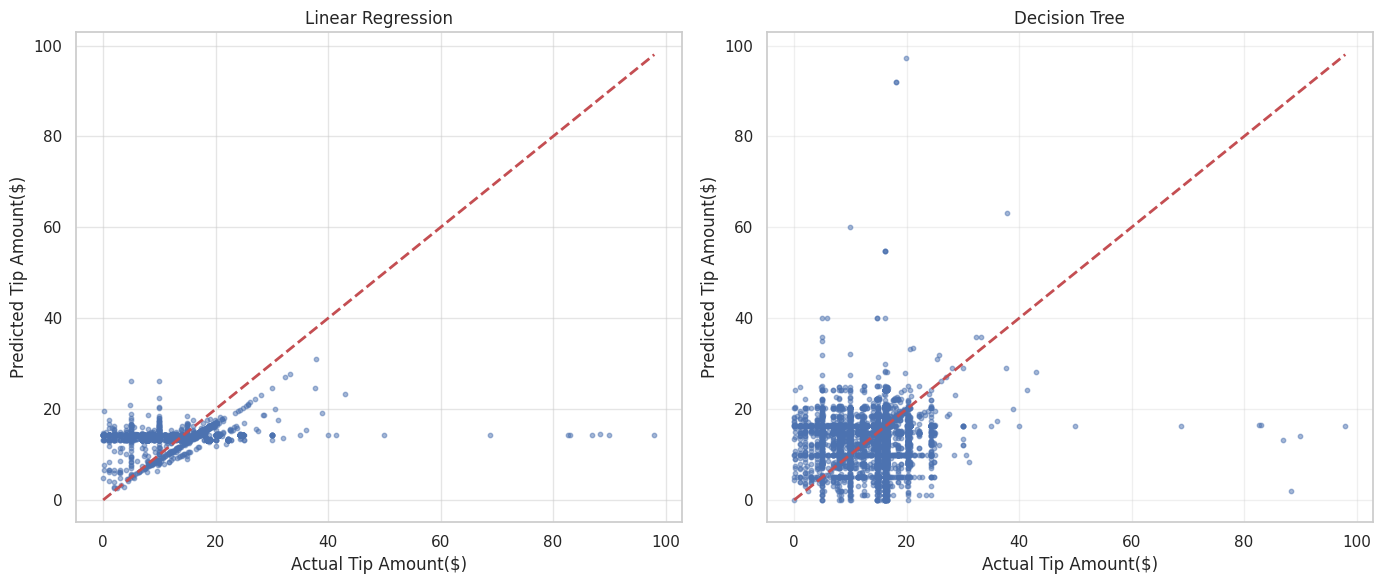

In [ ]:
#Part 1.4- Train a regresssor and check for overfitting
# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

# TODO: Predict on train, validation, and test sets.

# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line)
#Importing Required Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error , r2_score
import numpy as np
import matplotlib.pyplot as plt


#Initialise and train a regression model using linear regression
linear_model = LinearRegression()
linear_model.fit(X_train_scaled,y_train)

#Predict on train, validation, and test sets.

linear_train_prediction = linear_model.predict(X_train_scaled)
linear_val_prediction = linear_model.predict(X_val_scaled)
linear_test_prediction = linear_model.predict(X_test_scaled)

#Report RMSE and R^2 for ALL THREE sets.
linear_train_rmse = np.sqrt(mean_squared_error(y_train,linear_train_prediction))
linear_val_rmse = np.sqrt(mean_squared_error(y_val,linear_val_prediction))
linear_test_rmse = np.sqrt(mean_squared_error(y_test,linear_test_prediction))


linear_train_r2 = r2_score(y_train,linear_train_prediction)
linear_val_r2 = r2_score(y_val,linear_val_prediction)
linear_test_r2 = r2_score(y_test,linear_test_prediction)


print("Linear Regression Results:")
print(f"Train RMSE: {linear_train_rmse:.4f},R^2: {linear_train_r2:.4f}")
print(f"Validation RMSE: {linear_val_rmse:.4f},R^2: {linear_val_r2:.4f}")
print(f"Test RMSE: {linear_test_rmse:.4f},R^2: {linear_test_r2:.4f}")


#Initialise and train a regression model using decision tree regression

decisiontree_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
decisiontree_model.fit(X_train_scaled,y_train)


#Predict on train, validation, and test sets.

decisiontree_train_prediction =decisiontree_model.predict(X_train_scaled)
decisiontree_val_prediction =decisiontree_model.predict(X_val_scaled)
decisiontree_test_prediction = decisiontree_model.predict(X_test_scaled)

#Report RMSE and R^2 for ALL THREE sets.
decisiontree_train_rmse = np.sqrt(mean_squared_error(y_train,decisiontree_train_prediction))
decisiontree_val_rmse = np.sqrt(mean_squared_error(y_val,decisiontree_val_prediction))
decisiontree_test_rmse = np.sqrt(mean_squared_error(y_test,decisiontree_test_prediction))


decisiontree_train_r2 = r2_score(y_train,decisiontree_train_prediction)
decisiontree_val_r2 = r2_score(y_val,decisiontree_val_prediction)
decisiontree_test_r2 = r2_score(y_test,decisiontree_test_prediction)


print("Decision Tree Regression Results:")
print(f"Train RMSE: {decisiontree_train_rmse:.4f},R^2: {decisiontree_train_r2:.4f}")
print(f"Validation RMSE: {decisiontree_val_rmse:.4f},R^2: {decisiontree_val_r2:.4f}")
print(f"Test RMSE: {decisiontree_test_rmse:.4f},R^2: {decisiontree_test_r2:.4f}")


#Compare results and check for overfitting

#A comparison table
print("\nComparison of Models")


print("\nLinear Regression:")
print(f"Train RMSE: {linear_train_rmse:.4f},R^2: {linear_train_r2:.4f}")
print(f"Validation RMSE: {linear_val_rmse:.4f},R^2: {linear_val_r2:.4f}")
print(f"Test RMSE: {linear_test_rmse:.4f},R^2: {linear_test_r2:.4f}")


print("\nDecision Tree:")
print(f"Train RMSE: {decisiontree_train_rmse:.4f},R^2: {decisiontree_train_r2:.4f}")
print(f"Validation RMSE: {decisiontree_val_rmse:.4f},R^2: {decisiontree_val_r2:.4f}")
print(f"Test RMSE: {decisiontree_test_rmse:.4f},R^2: {decisiontree_test_r2:.4f}")


# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line)

fig, (ax1,ax2) = plt.subplots(1,2, figsize=(14,6))

#Linear Regression Model

ax1.scatter(y_test,linear_test_prediction, alpha = 0.5 ,s=10)
ax1.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
ax1.set_xlabel("Actual Tip Amount($)")
ax1.set_ylabel("Predicted Tip Amount($)")
ax1.set_title("Linear Regression")
ax1.grid(True, alpha = 0.5)


#Decision Tree Model

ax2.scatter(y_test,decisiontree_test_prediction, alpha = 0.5 ,s=10)
ax2.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
ax2.set_xlabel("Actual Tip Amount($)")
ax2.set_ylabel("Predicted Tip Amount($)")
ax2.set_title("Decision Tree")
ax2.grid(True, alpha = 0.3)


plt.tight_layout()
plt.show()

1. Which model performed best on the validation set, and which hyper-parameters did you try?

The linear regression model performed best on the validation set. For a model to be considered to have performed better on the validation set its validation for RMSE must be lower and its Validation R^2 must be higher ,closer to 1.0.
The Validation RMSE and Validation R^2 for Linear Regression was 5.0370 and 0.0487 respectively.

The Validation RMSE and Validation R^2 for Decision Tree was 6.7631 and -0.7150 respectively.
Therefore Linear Regression performed best based on the validation set.


I used the default hyper-parameters for both models. LinearRegression() for linear regression and
random_state = RANDOM_STATE for Decision Tree

2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim.

For linear regression, the model is underfitting.This is because all the three sets have approximately 5.0 RMSE and R^2 is approximately 0.05.The values are consistent accross all sets and R^s is very low (0.05) it doesn't explain anything.For Train the RMSE is 4.8046 and its R^2 is 0.0513. For Validation,the RMSE is 5.0370 and its R^2 is 0.0487.
For Test,the RMSE is 5.0132 and its R^2 is 0.0511.


For decision tree, the model is overfitting. There is a huge gap of 1.53 between the train and test performance.Train R^2 is 0.77 and Test R^2 is -0.76 with a difference of 1.53.

 3. What would you change to reduce overfitting if you saw it?
 To reduce overfitting in the decision tree, I would use a limit tree depth to prevent the tree from memeorising the training data.I would increase minimum samples to be splitted so that more samples would be required before splitting a node. Lastly, I would use a better model like Random Forest which is more robust to overfitting.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

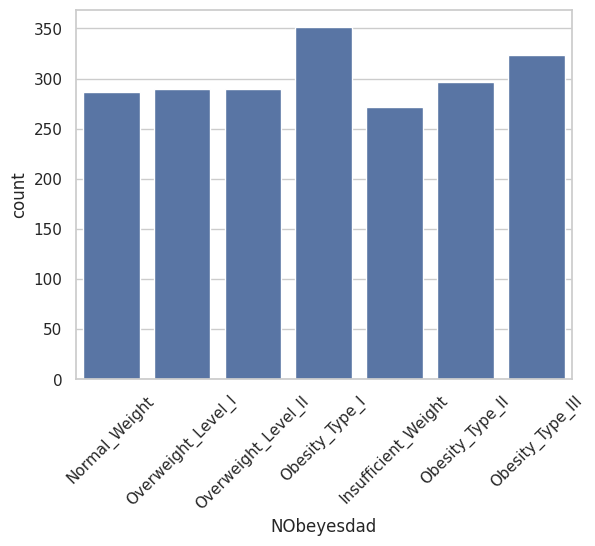

In [ ]:
#Supervised Learning

#Part 2.1

# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`

obesity = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv")
# TODO: Inspect shape, head, info, describe, and missing values.

#Inspect shape
obesity.shape
#There are 2111 rows(observations) and 17 columns(variables)

obesity.head()

obesity.info()
#Categorical Columns:Gender, family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
#Numeric columns: Age,Weight,Height,FCVC,NCP,CH20,FAF,TUE

obesity.describe()

obesity.isna().sum()
#There are no missing values
# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
obesity["NObeyesdad"].value_counts()
#The classes have roughly similar numbers.The 7 classes appear reasonably balanced

#A countplot
sns.countplot(data=obesity,x="NObeyesdad")
plt.xticks(rotation=45)
plt.show()

How many rows/features are there?

There are 2111 rows(observations) and 17 columns(variables)

Which columns are categorical vs numeric?

Categorical Columns:Gender, family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad

Numeric columns: Age,Weight,Height,FCVC,NCP,CH20,FAF,TUE


 Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?

 The target "NObeyesdad" is reasonably balanced across the 7 classes.The smallest has 272 observations and the largest has 351 observations.Since they are roughly similar there is no imbalance.

 Class balance matters for classification because, if a dataset is imbalanced ,it would cause the model to have high accuracy by predicting  the majority class most of the time while performing poorly on minority classes.

In [ ]:
#Preprocessing & Feature Engineering
# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

#Reloading the data
obesity =pd.read_csv(OBESITY_URL)
#Encoding Categorical Columns
#Manual mapping was used for these columns because they have only two meaningful values
obesity["family_history_with_overweight"].unique()
obesity["FAVC"].unique()
obesity["SMOKE"].unique()
obesity["SCC"].unique()

binary_map = {
    "yes":1,
    "no":0
}

#Applying encoding
obesity["family_history_with_overweight"] = obesity["family_history_with_overweight"].map(binary_map)
obesity["family_history_with_overweight"].unique()

obesity["FAVC"] = obesity["FAVC"].map(binary_map)
obesity["FAVC"].unique()

obesity["SMOKE"] = obesity["SMOKE"].map(binary_map)
obesity["SMOKE"].unique()

obesity["SCC"] = obesity["SCC"].map(binary_map)
obesity["SCC"].unique()

#Encoding Ordinal-Ish Columns
#I used ordinal encoding for this becuase their categories have a meaningful order
#(no,sometimes,frequently,always).This method preserves the ranking information.
obesity["CAEC"].unique()
obesity["CALC"].unique()


ordinal_map ={
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}


obesity["CAEC"] = obesity["CAEC"].map(ordinal_map)
obesity["CAEC"].unique()

obesity["CALC"] = obesity["CALC"].map(ordinal_map)
obesity["CALC"].unique()

#Encoding Nominal
obesity["Gender"].unique()
obesity["MTRANS"].unique()

#Since no natural order exits for these categorical variables, one-hot encoding will be used
#It creates a separate binary indicator variable for each category.
obesity = pd.get_dummies(
    obesity,
    columns =["Gender","MTRANS"],
    drop_first= True
)

obesity.head()
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
obesity["BMI"] = obesity["Weight"]/(obesity["Height"] **2)
obesity[["Height","Weight","BMI"]].head()

#BMI doesn't leak the target because it isn't calculated with the target"NObeyesdad"
#but since it is strongly related to obesity, it might make the target too easy.

# TODO: Encode the target `NObeyesdad` into integer class labels
from sklearn.preprocessing import LabelEncoder

#Create Encoder
target_encoder = LabelEncoder()

obesity["NObeyesdad"] = target_encoder.fit_transform(
    obesity["NObeyesdad"]
)


obesity["NObeyesdad"].head()

#Create X and y

y = obesity["NObeyesdad"]

x= obesity.drop("NObeyesdad",axis =1)
# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
from sklearn.preprocessing import StandardScaler


1. How did you encode each type of categorical variable, and why?

For Ordinal-Ish Columns, I used ordinal encoding for this becuase their categories have a meaningful order
(no,sometimes,frequently,always).This method preserves the ranking information

For Binary Columns,Manual mapping was used for these columns because they have only two meaningful values.

For Nominal Columns ,since no natural order exits for these categorical variables, one-hot encoding was used .It creates a separate binary indicator variable for each category.

2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level.

Yes,I engineered BMI.It is somewhat unfair because it's related to obesity levels so it may improve the model's predictive performance and also make classification easier.But it isn't a target leakage because ,the target "NObeyesdad" isn't included in its calculation.

3. Which scaler did you use and why?
I used a StandardScaler to standardise the numeric features so that they can have a mean of 0 and a standard deviation of 1.This isbecause the numeric variables are measured on different scales. The scalar was fitted on only the training data to avoid data leakage.

In [ ]:
# Stratified Train / Validation / Test split

# TODO: Separate X (features) and y (encoded NObeyesdad).
X= obesity.drop("NObeyesdad",axis=1)
y = obesity["NObeyesdad"]

print(X.shape)
print(y.shape)

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.
from sklearn.model_selection import train_test_split
#Split ratio is 70% for training, 15% for Validation , 15% for test

#Create th test set (15%)
X_train_val, X_test,y_train_val,y_test = train_test_split(
    X,
    y,
    test_size = 0.15,
    stratify=y,
    random_state = RANDOM_STATE
)
#stratify = y preserves the class proportions

#Splitting the remaining 85%
X_train, X_val,y_train,y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size = 0.176,
    stratify=y_train_val,
    random_state = RANDOM_STATE
)

#Check sizes

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

# TODO: Fit the scaler on the training set only, then transform train / val / test.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#Fit on Train only
scaler.fit(X_train)

#Transform Train/Val/Test
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



(2111, 20)
(2111,)
(1478, 20)
(316, 20)
(317, 20)


What split ratio did you choose?
The Split ratio is 70% for training, 15% for Validation , 15% for test


Why is stratify=y important for this dataset?
Since NObeyesdad contains 7 classes, stratify = y ensures the same  proportion for each class as the original dataset.


What could go wrong if you split without stratifying?
Some classes would be overpresented or underpresented in certain splits.Or a particular class might have few or no observations in its test or validation test and this could make the model give false prediction.

X_train: (1478, 20)
X_val: (316, 20)
X_test: (317, 20)
y_train: (1478,)
y_val: (316,)
y_test: (317,)
X_train_scaled: (1478, 20)
X_val_scaled: (316, 20)
X_test_scaled: (317, 20)
Train Accuracy: 0.9242219215155616
Validation Accuracy: 0.9050632911392406
Test Accuracy: 0.886435331230284
Train Macro-F1: 0.9213829146427048
Validation Macro-F1: 0.9020916618826131
Test Macro-F1: 0.8805196818676359
              precision    recall  f1-score   support

           0       0.89      0.98      0.93        41
           1       0.78      0.67      0.72        43
           2       0.91      0.96      0.94        53
           3       0.96      1.00      0.98        45
           4       1.00      0.98      0.99        49
           5       0.73      0.81      0.77        43
           6       0.92      0.77      0.84        43

    accuracy                           0.89       317
   macro avg       0.88      0.88      0.88       317
weighted avg       0.89      0.89      0.88       317



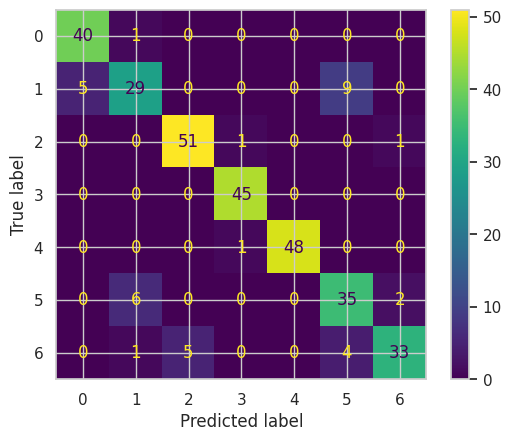

['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']


In [ ]:
#Train a classifier and check for overfitting
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).

#Check the dataset sizes
print("X_train:", X_train.shape)
print("X_val:",X_val.shape)
print("X_test:",X_test.shape)

print("y_train:",y_train.shape)
print("y_val:",y_val.shape)
print("y_test:",y_test.shape)


print("X_train_scaled:",X_train_scaled.shape)
print("X_val_scaled:",X_val_scaled.shape)
print("X_test_scaled:",X_test_scaled.shape)
#Since the data has been scaled,I would use LogisticRegression

#Import
from sklearn.linear_model import LogisticRegression

#initialise the model

model = LogisticRegression(
    max_iter = 1000,
    random_state = RANDOM_STATE
)


#Train
# TODO: Predict on train, validation, and test.
#Train
model.fit(X_train_scaled,y_train)

#Make predictions
y_train_prediction = model.predict(X_train_scaled)

y_val_prediction = model.predict(X_val_scaled)

y_test_prediction = model.predict(X_test_scaled)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

#Calculate Accuracy
train_accuracy = accuracy_score(y_train,y_train_prediction)
val_accuracy = accuracy_score(y_val,y_val_prediction)
test_accuracy = accuracy_score(y_test,y_test_prediction)

print("Train Accuracy:" ,train_accuracy)
print("Validation Accuracy:",val_accuracy)
print("Test Accuracy:",test_accuracy)


#Calculate Micro-F1
train_f1= f1_score(
    y_train,
    y_train_prediction,
    average="macro"
)

val_f1= f1_score(
    y_val,
    y_val_prediction,
    average="macro"
)

test_f1= f1_score(
    y_test,
    y_test_prediction,
    average="macro"
)

print("Train Macro-F1:",train_f1)
print("Validation Macro-F1:",val_f1)
print("Test Macro-F1:",test_f1)


print(classification_report(y_test,y_test_prediction))
# TODO: Show a confusion matrix for the test set

#Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
      y_test,
      y_test_prediction
)

plt.show()
#   Which classes are most often confused?
#actual obesity names which are often confused
print(target_encoder.classes_)
#['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
# 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']

#The largest off-diagonal value was 9 located at (1,5).From my label mapping,
#row 1 corresponds to Normal_Weight.So this implies that Normal_Weight was predicted as Overweight_Level_I 9 times.

 1. Which classifier did you choose and why?
I chose Logistic Regression because it is an efficient classifier for multi-class classification problems.It is easy to interpret and works well with standardised numerical features.

2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics.

The model is well-fitted with slight overfitting. The training accuracy is 0.9242 and its Macro-F1 is 0.9214 which is higher than the validation accuracy and macro-F1 which is 0.9051 and 0.9021 respectively.It's also higher than the test accuracy and macro-FI which is 0.8864 and 0.8805 respectively.However, the differences between the training accuracy/F1 and that of test and validation is relatively small this indicates that the model has good predictive performance with only a small amount of overfitting.

3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?

The obesity levels which are hardest to tell apart are Normal_Weight and Overweight_Level_I.Other obesity levels which are hardest to tell apart are Overweight_Level_II and Obesity_Type_I.These classes are obesity levels that are next to each other so individuals in them mostly have similar features such as BMI which makes it difficult to tell them apart.

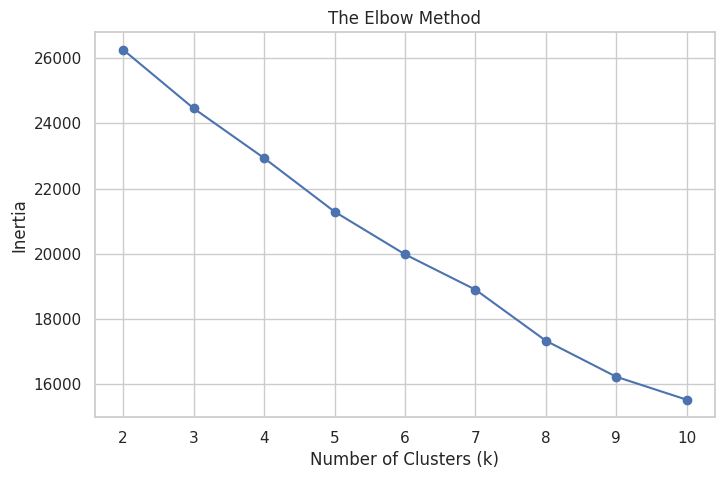

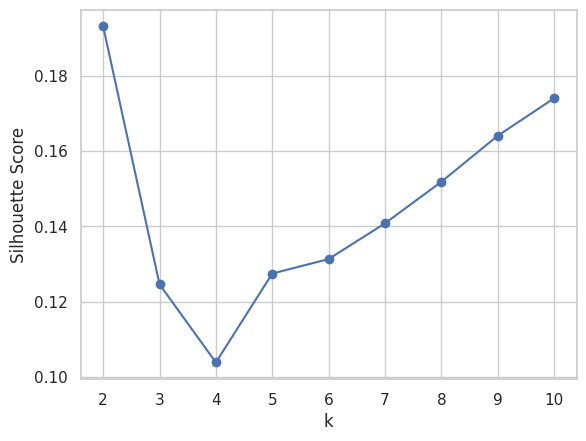

chosen_k: 2 , score: 0.193


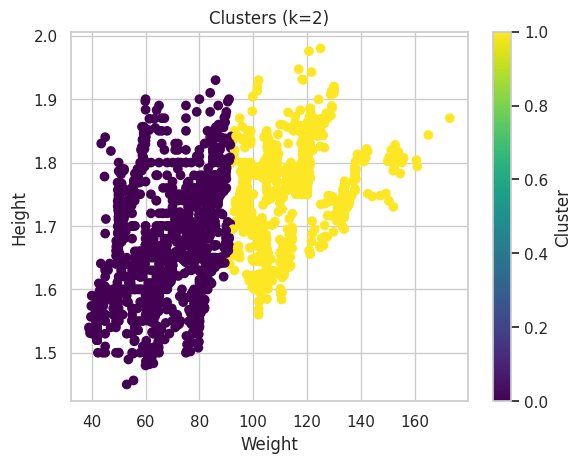

In [ ]:
#Unsupervised Learning (K-Means Clustering)

#Part 3.1
#Choose k, fit K-Means, and visualise
# TODO: Use ONLY the scaled obesity features (no target) for clustering.
X_cluster = X_train_scaled



# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow Method
inertias =[]
silhouette_scores = []

#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
for k in range (2,11):
  kmeans = KMeans(
      n_clusters =k,
      random_state = RANDOM_STATE,
      n_init = 10
  )

  kmeans.fit(X_cluster)

  inertias.append(kmeans.inertia_)

  silhouette_scores.append(
      silhouette_score(X_cluster,kmeans.labels_)
  )

#The Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(2,11),inertias,marker ="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("The Elbow Method")

plt.show()



#Choosing a k-value using the silhouette plot
plt.plot(range(2,11),silhouette_scores,marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.show()

#The k with the highest score becomes my chosen k
chosen_k = range(2,11)[silhouette_scores.index(max(silhouette_scores))]
print(f"chosen_k: {chosen_k} , score: {max(silhouette_scores):.3f}")

#k = 2
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
kmeans = KMeans(n_clusters = 2, random_state= 42, n_init =10)
cluster_labels = kmeans.fit_predict(X)

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

#Weight vs Height

#Index position of weight and height
obesity.columns.get_loc('Weight')
#Index Weight = 2
obesity.columns.get_loc('Height')
#Index Height =1

#Extract features
info_feature1 = X['Weight']
info_feature2 = X['Height']

#Scatter plot
plt.scatter(info_feature1,info_feature2,c=cluster_labels,cmap='viridis')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title('Clusters (k=2)')
plt.colorbar(label='Cluster')



In [ ]:
# TODO: How well do the clusters line up with the TRUE obesity levels?

X_full = obesity.drop("NObeyesdad",axis =1)

scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)

kmeans = KMeans (
    n_clusters = 2,
    random_state = RANDOM_STATE,
    n_init = 10
)



cluster_labels = kmeans.fit_predict(X_full_scaled)

print(cluster_labels[:10])
#   Build a crosstab of cluster label vs the real NObeyesdad category:
pd.crosstab(cluster_labels, obesity['NObeyesdad'])

#   Do some clusters map cleanly onto specific obesity levels?
#The clusters do not map cleanly onto specific obesity levels. Cluster 0 contains individuals who are in the category (Insufficient_Weight and Normal_Weight) and Cluster 1 has individuals who are of the category
#(Obesity_Type_I,Obesity_Type_II and Obesity_Type_III).This means that K-means grouped lower-weight individuals in
#a cluster and higher weight and obese individuals in another cluster.It grouped them based on similar features.

[0 0 0 0 0 0 0 0 1 0]


NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,266,272,22,1,0,135,85
1,6,15,329,296,324,155,205


1. How did you choose k? Quote the Elbow/silhouette evidence.
I chose k by analysing the silhouette plot.From the plot , the k-value with the highest score is the most suitable because , it implies that it would create a better separation between the clusters.k= 2 had the highest silhouette score of about 0.19.

2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down?

The unsupervised clusters resemble real obesity levels to an extent.Cluster 0 contains individuals who are in the category (Insufficient_Weight and Normal_Weight) and Cluster 1 has individuals who are of the category
(Obesity_Type_I,Obesity_Type_II and Obesity_Type_III).This means that K-means grouped lower-weight individuals in  a cluster and higher weight and obese individuals in another cluster.It grouped them based on similar features.
Where they agree: It was able to separate them into lower-weight and higher weight(obese) groups.
Where they break down: The clusters  do not map cleanly onto specific obesity levels.From the crosstab,the overweight categories are spread across the clusters and several obesity levels are grouped together.

3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?

They could be used to identify individuals with similar health characteristics.

Supervised vs unsupervised:
What did the classifier learn that K-Means could not, and vice-versa?

Classifier was able to segregate them into categories that matched their obesity levels because it learned from labeled examples. K-means couldn't match them based on their obesity levels because it didn't have access to any labeled data.

K-means was able to identify the patterns and grouped similar people based on observations but the classifier couldn't  do so based on observations but rather labeled data.

Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
In evaluating tip_amount,we check how close predictions are to the true numerical value since it was a continuous variable and not discrete.If tip_amount is like 0.5 and the actual is 1,the prediction could be termed to be true.

In evaluating obesity levels we evaluate whether the predicted class is the same as the true class. In other words , if the prediction is Overweight , the true class must be Overweight and not Obesity_Level_I .

Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

The biggest train-vs-test gap can be seen in the Decision Tree Regression model.On the training set,it had an R^2 score of 0.7669 and an RMSE of 2.3816 which signified that it did a good work on the training data tesr. But on the test set, the R^2 score dropped to -0.7568 and the RMSE increased to 6.8212. This shows that the model memorised the training data and did not generalise well to unseen data which indicates overfitting. To reduce overfitting, the complexity of the decision tree will be limited by pruning the tree so that it focuses on the most important patterns instead of memorising the training data